<a href="https://colab.research.google.com/github/tejas883/Roll_No_32_Machine-Learning-Lab/blob/main/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Tejas Surendra Mule

Roll no : CS32

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


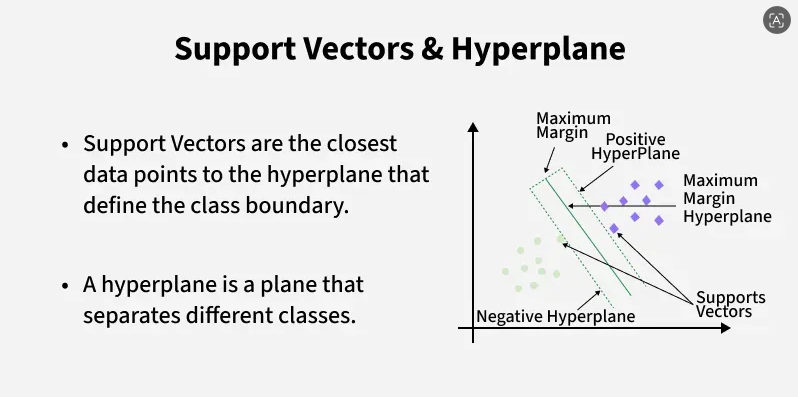
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
# ============================================
# Task 1: Import Libraries and Load Dataset
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# Manually select the dataset
uploaded = files.upload()

# Get the name of the selected file automatically
file_name = list(uploaded.keys())[0]

print("Selected file:", file_name)

# Load the selected dataset
df = pd.read_csv(file_name)

# Display first 5 rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Display shape
print("\nShape of the dataset:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display class distribution
print("\nClass Distribution:")
print(df["Species"].value_counts())

Saving Iris (2).csv to Iris (2) (1).csv
Selected file: Iris (2) (1).csv

First 5 rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Shape of the dataset:
(150, 6)

Column names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalL

# Task 2: Explore the Dataset

In [ ]:
# ============================================
# Task 2: Explore the Dataset
# ============================================

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Display last 5 rows
print("\nLast 5 rows:")
print(df.tail())

# Display number of rows and columns
print("\nShape of the dataset:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns)

# Display data types
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Display unique classes
print("\nUnique classes:")
print(df["Species"].unique())

# Display number of samples in each class
print("\nClass distribution:")
print(df["Species"].value_counts())

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Last 5 rows:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
145  Iris-virginica  
146  Iris-virginica  
147  Iris-virginica  
1

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# ============================================
# Task 3: Select Features and Target
# ============================================

# Remove the Id column
df = df.drop("Id", axis=1)

# Select the features
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

# Select the target
y = df["Species"]

# Display features
print("Selected Features:")
print(X.head())

# Display target
print("\nTarget:")
print(y.head())

# Display feature shape
print("\nFeature shape:", X.shape)

# Display target shape
print("Target shape:", y.shape)

# Display target classes
print("\nTarget classes:")
print(y.unique())

Selected Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

Feature shape: (150, 4)
Target shape: (150,)

Target classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
# ============================================
# Task 4: Split and Scale the Data
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Display scaled training data
print("\nFirst 5 rows of scaled training data:")
print(X_train_scaled[:5])

Training data shape: (120, 4)
Testing data shape: (30, 4)

Training target shape: (120,)
Testing target shape: (30,)

First 5 rows of scaled training data:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
# ============================================
# Task 5: Implement Linear SVM
# ============================================

from sklearn.svm import SVC

# Create Linear SVM model
linear_svm = SVC(kernel="linear", random_state=42)

# Train the model
linear_svm.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred_linear = linear_svm.predict(X_test_scaled)

# Display predictions
print("Predicted values:")
print(y_pred_linear)

print("\nActual values:")
print(y_test.values)

Predicted values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']

Actual values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


Accuracy of Linear SVM:
1.0

Accuracy in percentage:
100.0 %

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


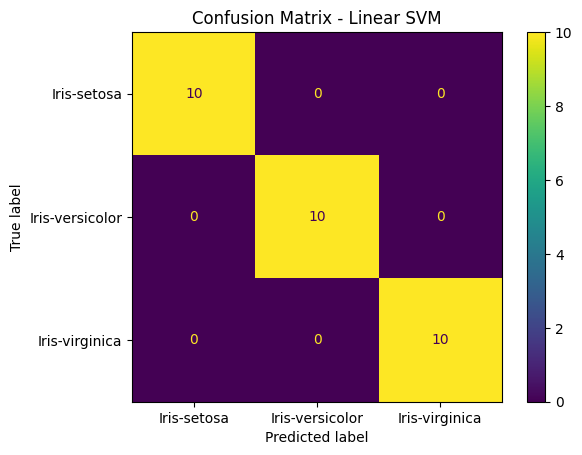


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:
# ============================================
# Task 6: Evaluate Linear SVM
# ============================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_linear)

print("Accuracy of Linear SVM:")
print(accuracy)

print("\nAccuracy in percentage:")
print(accuracy * 100, "%")


# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred_linear)

print("\nConfusion Matrix:")
print(cm)


# Display confusion matrix as a graph
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=linear_svm.classes_
)

disp.plot()
plt.title("Confusion Matrix - Linear SVM")
plt.show()


# ============================================
# Classification Report
# ============================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

Selected Features:
   PetalLengthCm  PetalWidthCm
0            1.4           0.2
1            1.4           0.2
2            1.3           0.2
3            1.5           0.2
4            1.4           0.2

Shape of 2-D dataset:
(150, 2)

Training data shape: (120, 2)
Testing data shape: (30, 2)

Linear SVM trained successfully!


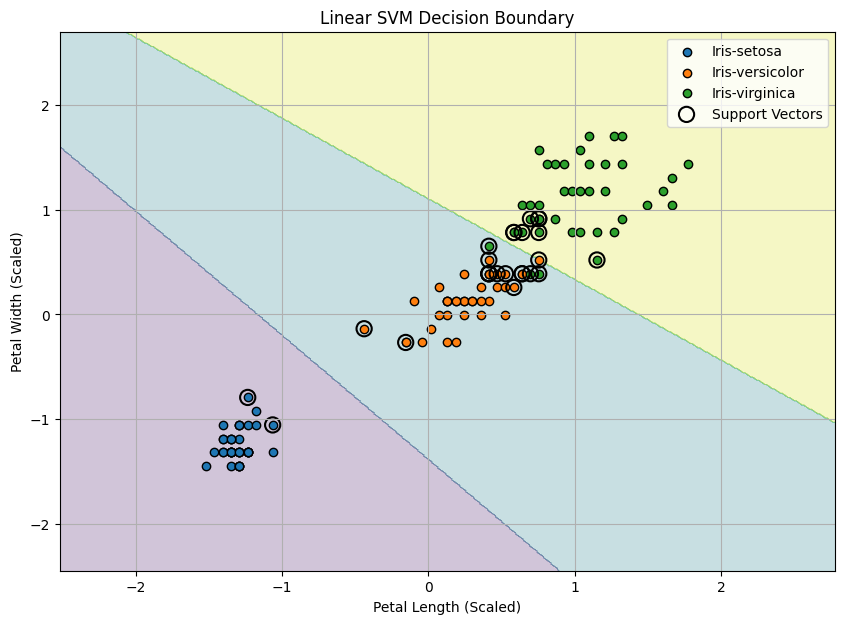

In [ ]:
# ============================================
# Task 7: Visualize SVM Decision Boundary
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Step 1: Create the 2-D Dataset
# --------------------------------------------

X_2D = df[["PetalLengthCm", "PetalWidthCm"]]
y_2D = df["Species"]

print("Selected Features:")
print(X_2D.head())

print("\nShape of 2-D dataset:")
print(X_2D.shape)


# --------------------------------------------
# Step 2: Split the Data
# --------------------------------------------

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.20,
    random_state=42,
    stratify=y_2D
)

print("\nTraining data shape:", X_train_2D.shape)
print("Testing data shape:", X_test_2D.shape)


# --------------------------------------------
# Step 3: Scale the Data
# --------------------------------------------

scaler_2D = StandardScaler()

X_train_2D_scaled = scaler_2D.fit_transform(X_train_2D)
X_test_2D_scaled = scaler_2D.transform(X_test_2D)


# --------------------------------------------
# Step 4: Train Linear SVM
# --------------------------------------------

svm_2D = SVC(kernel="linear", random_state=42)

svm_2D.fit(X_train_2D_scaled, y_train_2D)

# Make predictions
y_pred_2D = svm_2D.predict(X_test_2D_scaled)

print("\nLinear SVM trained successfully!")


# --------------------------------------------
# Step 5: Create Mesh Grid
# --------------------------------------------

x_min = X_train_2D_scaled[:, 0].min() - 1
x_max = X_train_2D_scaled[:, 0].max() + 1

y_min = X_train_2D_scaled[:, 1].min() - 1
y_max = X_train_2D_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


# --------------------------------------------
# Step 6: Predict Each Point in the Grid
# --------------------------------------------

Z = svm_2D.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert predictions to numerical values
class_values = {
    class_name: index
    for index, class_name in enumerate(svm_2D.classes_)
}

Z = np.array([class_values[value] for value in Z])
Z = Z.reshape(xx.shape)


# --------------------------------------------
# Step 7: Plot Decision Boundary
# --------------------------------------------

plt.figure(figsize=(10, 7))

# Plot decision regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

# Plot training data
for class_name in svm_2D.classes_:

    class_index = y_train_2D == class_name

    plt.scatter(
        X_train_2D_scaled[class_index, 0],
        X_train_2D_scaled[class_index, 1],
        label=class_name,
        edgecolors="black"
    )


# Plot support vectors
plt.scatter(
    svm_2D.support_vectors_[:, 0],
    svm_2D.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Logistic Regression model trained successfully!

Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


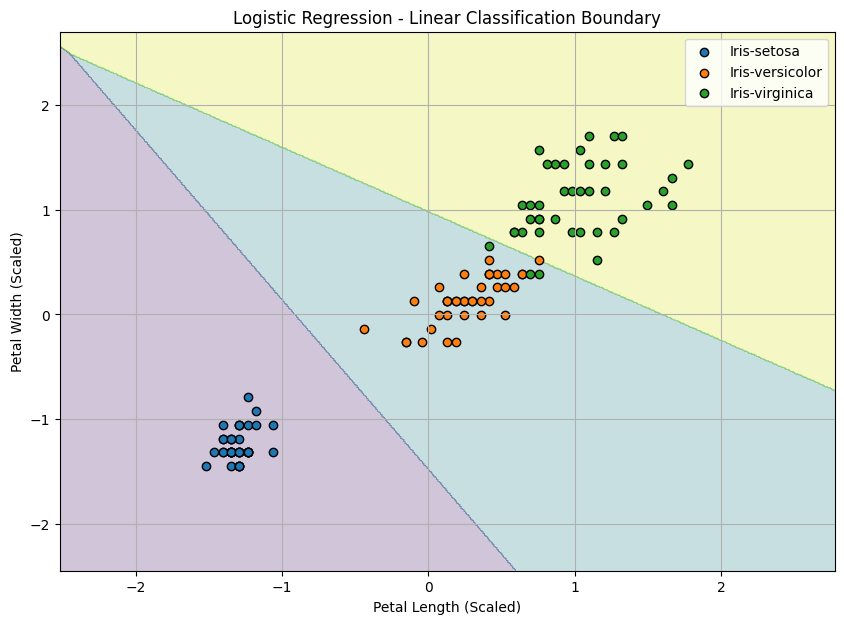

In [ ]:
# ============================================
# Task 8: Normal Linear Classification Boundary
# ============================================

from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Step 1: Create Logistic Regression model
# --------------------------------------------

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# --------------------------------------------
# Step 2: Train the model
# --------------------------------------------

logistic_model.fit(X_train_2D_scaled, y_train_2D)

print("Logistic Regression model trained successfully!")


# --------------------------------------------
# Step 3: Make predictions
# --------------------------------------------

y_pred_logistic = logistic_model.predict(X_test_2D_scaled)

print("\nPredictions:")
print(y_pred_logistic)


# --------------------------------------------
# Step 4: Create mesh grid
# --------------------------------------------

x_min = X_train_2D_scaled[:, 0].min() - 1
x_max = X_train_2D_scaled[:, 0].max() + 1

y_min = X_train_2D_scaled[:, 1].min() - 1
y_max = X_train_2D_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


# --------------------------------------------
# Step 5: Predict classes for mesh grid
# --------------------------------------------

Z = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert class names to numbers
class_values = {
    class_name: index
    for index, class_name in enumerate(logistic_model.classes_)
}

Z = np.array([class_values[value] for value in Z])
Z = Z.reshape(xx.shape)


# --------------------------------------------
# Step 6: Plot Logistic Regression
# --------------------------------------------

plt.figure(figsize=(10, 7))

# Plot decision regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

# Plot training data
for class_name in logistic_model.classes_:

    class_index = y_train_2D == class_name

    plt.scatter(
        X_train_2D_scaled[class_index, 0],
        X_train_2D_scaled[class_index, 1],
        label=class_name,
        edgecolors="black"
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression - Linear Classification Boundary")
plt.legend()
plt.grid(True)

plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

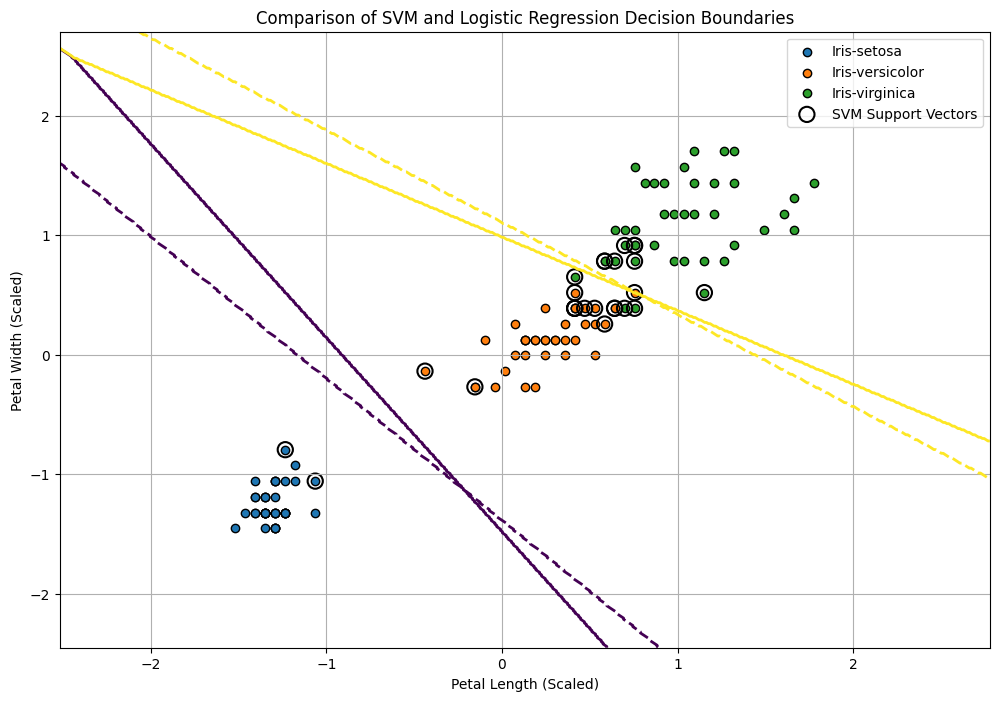

In [ ]:
# Task 9: Compare SVM and Logistic Regression Decision Boundaries

import numpy as np
import matplotlib.pyplot as plt

# Create a mesh grid
x_min = X_train_2D_scaled[:, 0].min() - 1
x_max = X_train_2D_scaled[:, 0].max() + 1
y_min = X_train_2D_scaled[:, 1].min() - 1
y_max = X_train_2D_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# -------------------------
# SVM Predictions
# -------------------------
Z_svm = svm_2D.predict(np.c_[xx.ravel(), yy.ravel()])

svm_class_values = {
    class_name: index
    for index, class_name in enumerate(svm_2D.classes_)
}

Z_svm = np.array([
    svm_class_values[value]
    for value in Z_svm
])

Z_svm = Z_svm.reshape(xx.shape)


# -------------------------
# Logistic Regression Predictions
# -------------------------
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

logistic_class_values = {
    class_name: index
    for index, class_name in enumerate(logistic_model.classes_)
}

Z_logistic = np.array([
    logistic_class_values[value]
    for value in Z_logistic
])

Z_logistic = Z_logistic.reshape(xx.shape)


# -------------------------
# Plot Both Boundaries
# -------------------------
plt.figure(figsize=(12, 8))

# SVM boundary
plt.contour(
    xx,
    yy,
    Z_svm,
    levels=[0.5, 1.5],
    linestyles="--",
    linewidths=2
)

# Logistic Regression boundary
plt.contour(
    xx,
    yy,
    Z_logistic,
    levels=[0.5, 1.5],
    linestyles="-",
    linewidths=2
)

# Plot training points
for class_name in svm_2D.classes_:
    class_index = y_train_2D == class_name

    plt.scatter(
        X_train_2D_scaled[class_index, 0],
        X_train_2D_scaled[class_index, 1],
        label=class_name,
        edgecolors="black"
    )

# Highlight SVM support vectors
plt.scatter(
    svm_2D.support_vectors_[:, 0],
    svm_2D.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="SVM Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Comparison of SVM and Logistic Regression Decision Boundaries")

plt.legend()
plt.grid(True)
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

===== ACCURACY COMPARISON =====
Linear SVM Accuracy:
0.9333333333333333

Linear SVM Accuracy (%):
93.33333333333333 %

Logistic Regression Accuracy:
0.9333333333333333

Logistic Regression Accuracy (%):
93.33333333333333 %

===== SVM CONFUSION MATRIX =====
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

===== LOGISTIC REGRESSION CONFUSION MATRIX =====
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


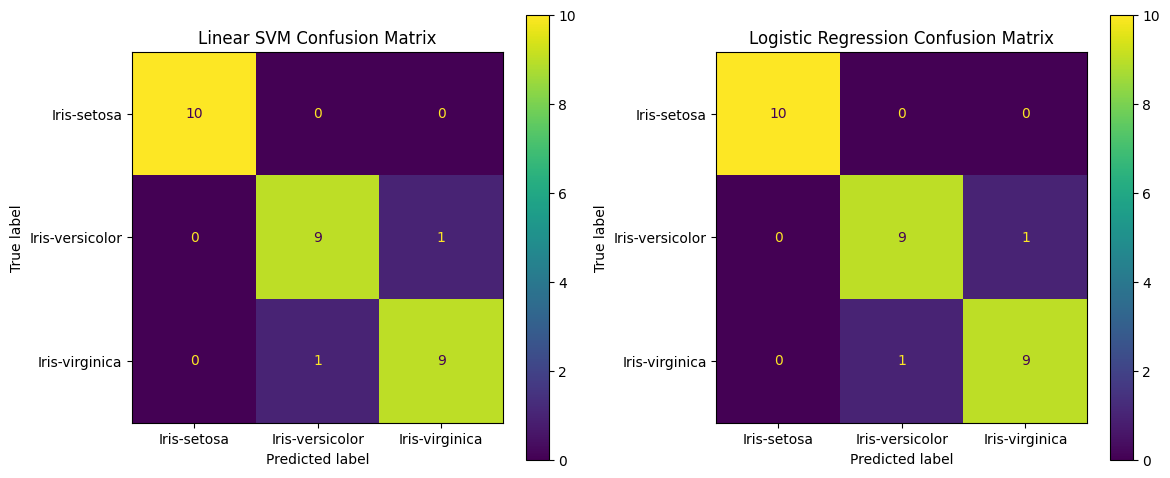


===== LINEAR SVM CLASSIFICATION REPORT =====
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [ ]:
# Task 10: Compare Performance of Linear SVM and Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# --------------------------------
# 1. Accuracy
# --------------------------------

svm_accuracy = accuracy_score(y_test_2D, y_pred_2D)
logistic_accuracy = accuracy_score(y_test_2D, y_pred_logistic)

print("===== ACCURACY COMPARISON =====")

print("Linear SVM Accuracy:")
print(svm_accuracy)

print("\nLinear SVM Accuracy (%):")
print(svm_accuracy * 100, "%")

print("\nLogistic Regression Accuracy:")
print(logistic_accuracy)

print("\nLogistic Regression Accuracy (%):")
print(logistic_accuracy * 100, "%")


# --------------------------------
# 2. Confusion Matrix
# --------------------------------

svm_cm = confusion_matrix(y_test_2D, y_pred_2D)
logistic_cm = confusion_matrix(y_test_2D, y_pred_logistic)

print("\n===== SVM CONFUSION MATRIX =====")
print(svm_cm)

print("\n===== LOGISTIC REGRESSION CONFUSION MATRIX =====")
print(logistic_cm)


# --------------------------------
# 3. Display Confusion Matrices
# --------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=svm_2D.classes_
).plot(ax=axes[0])

axes[0].set_title("Linear SVM Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=logistic_model.classes_
).plot(ax=axes[1])

axes[1].set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()


# --------------------------------
# 4. Classification Reports
# --------------------------------

print("\n===== LINEAR SVM CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test_2D,
        y_pred_2D
    )
)

print("\n===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test_2D,
        y_pred_logistic
    )
)

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.